# Mérési notebook
---
# **3. mérési fázis**. A	Modellek tesztelése teljes tanítással.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 5. modell **ViT-B/16** modell teljes tanítással történő tesztelése

#### A ViT-B/16 modell tesztelése 1k, 5k, 10k, 25k tanítás után a saját SBphotothemes180k adathalmaz Test részhalmazán. (teszt elemszám: 18k).

---

🧪 ViT-B/16 – Few-shot Fine-tune – Notebook 1–5. blokk

✅ 1. Telepítés, importálás, GPU ellenőrzés

In [ ]:
!pip install -q timm torchvision scikit-learn matplotlib tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random, os, time
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, top_k_accuracy_score, confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🖥️ GPU elérhetőség:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 110.9 MB/s eta 0:00:00
🖥️ GPU elérhetőség: cuda


✅ 2. Drive csatolás, adatbázis kicsomagolása

In [ ]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')
diploma_path = "/content/drive/MyDrive/diplomamunka"
zip_path = os.path.join(diploma_path, "imagenet_splitted_db.zip")
extract_path = "/content/imagenet_splitted_db"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("✅ Adatok kibontva:", extract_path)


Mounted at /content/drive
✅ Adatok kibontva: /content/imagenet_splitted_db


Mappa pontosítás

In [ ]:
extract_path = "/content/imagenet_splitted_db/imagenet_splitted_db"

✅ 3. Adatok betöltése, részhalmazok stratifikált előállítása

In [ ]:
from collections import defaultdict

# Transzformáció ViT-re optimalizálva
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),  # ViT eredetileg 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Halmazok betöltése
train_dataset_full = datasets.ImageFolder(os.path.join(extract_path, "train"), transform=transform)
val_dataset         = datasets.ImageFolder(os.path.join(extract_path, "val"), transform=transform)
test_dataset        = datasets.ImageFolder(os.path.join(extract_path, "test"), transform=transform)

# Stratifikált mintavételezés
def stratified_subset(dataset, total_images):
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    per_class = total_images // len(class_indices)
    selected_indices = []

    for cls, indices in class_indices.items():
        chosen = random.sample(indices, min(per_class, len(indices)))
        selected_indices.extend(chosen)

    print(f"📦 Kiválasztott képek: {len(selected_indices)}")
    return Subset(dataset, selected_indices)

subset_sizes = [1000, 5000, 10000, 25000]
subsets = {f"{size}": stratified_subset(train_dataset_full, size) for size in subset_sizes}

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

class_names = train_dataset_full.classes
num_classes = len(class_names)


📦 Kiválasztott képek: 912
📦 Kiválasztott képek: 4902
📦 Kiválasztott képek: 9918
📦 Kiválasztott képek: 24966


✅ 4. ViT-B/16 modell betöltése új osztályszámmal

In [ ]:
import timm

def get_vit_model():
    model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)
    return model.to(device)


✅ 5. Általános tanítófüggvény ViT-hez

In [ ]:
def train_on_subset(train_dataset, subset_name, num_epochs=10):
    print(f"\n🚀 Tanítás: {subset_name} képes halmaz (ViT-B/16)")

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
    model = get_vit_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - train"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        # Validáció
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= total
        val_acc = correct / total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"📊 Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | Val loss={val_loss:.4f}, acc={val_acc:.4f}")

    return model, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist


🔷 BLOKK 6–9: Tanítás 1k / 5k / 10k / 25k részhalmazokon

Minden részhalmazra külön:

✅ Tanítás

📉 Tanulási görbék

🧪 Metrikák: Top-1 / Top-5 / Precision / Recall / F1 / Inference time


🔷 BLOKK 6 – ViT-B/16 @ 1k képes részhalmaz


🚀 Tanítás: 1k képes halmaz (ViT-B/16)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1/10 - train: 100%|██████████| 15/15 [00:07<00:00,  2.05it/s]


📊 Epoch 1: Train loss=4.6843, acc=0.0417 | Val loss=3.8488, acc=0.2340


...

📊 Epoch 8: Train loss=0.0146, acc=0.9956 | Val loss=2.8890, acc=0.3685


Epoch 9/10 - train: 100%|██████████| 15/15 [00:06<00:00,  2.36it/s]


📊 Epoch 9: Train loss=0.0106, acc=0.9967 | Val loss=2.9405, acc=0.3596


Epoch 10/10 - train: 100%|██████████| 15/15 [00:06<00:00,  2.36it/s]


📊 Epoch 10: Train loss=0.0052, acc=0.9989 | Val loss=2.9333, acc=0.3622


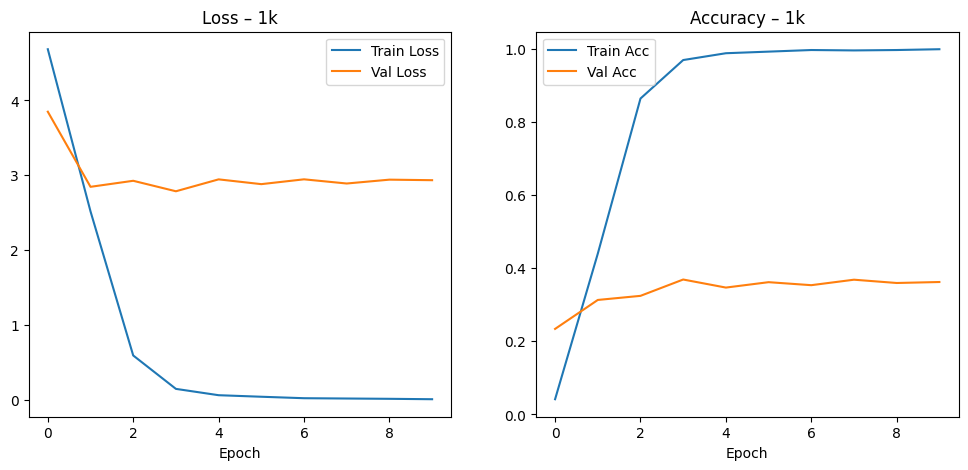


🔍 Metrikák – ViT-B/16 trained on 1k:
✅ Top-1 Accuracy:  0.3645
✅ Top-5 Accuracy:  0.6646
🎯 Precision:       0.3144
🎯 Recall:          0.3529
🎯 F1-score:        0.3138
⏱️ Inference time:  41.85 sec


In [ ]:
model_1k, train_loss_1k, val_loss_1k, train_acc_1k, val_acc_1k = train_on_subset(subsets["1000"], "1k", num_epochs=10)

# Tanulási görbe – 1k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_1k, label="Train Loss")
plt.plot(val_loss_1k, label="Val Loss")
plt.title("Loss – 1k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_1k, label="Train Acc")
plt.plot(val_acc_1k, label="Val Acc")
plt.title("Accuracy – 1k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# Tesztelés 1k modellen
model_1k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_1k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – ViT-B/16 trained on 1k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


🔷 BLOKK 7 – ViT-B/16 @ 5k részhalmaz


🚀 Tanítás: 5k képes halmaz (ViT-B/16)


Epoch 1/10 - train: 100%|██████████| 77/77 [00:32<00:00,  2.34it/s]


📊 Epoch 1: Train loss=3.3736, acc=0.2326 | Val loss=1.9799, acc=0.4640


Epoch 2/10 - train: 100%|██████████| 77/77 [00:32<00:00,  2.34it/s]


📊 Epoch 2: Train loss=1.3933, acc=0.6246 | Val loss=2.2583, acc=0.4311


...

📊 Epoch 8: Train loss=0.0367, acc=0.9916 | Val loss=2.6809, acc=0.4699


Epoch 9/10 - train: 100%|██████████| 77/77 [00:32<00:00,  2.34it/s]


📊 Epoch 9: Train loss=0.0757, acc=0.9814 | Val loss=2.6012, acc=0.4806


Epoch 10/10 - train: 100%|██████████| 77/77 [00:32<00:00,  2.34it/s]


📊 Epoch 10: Train loss=0.0750, acc=0.9816 | Val loss=2.9607, acc=0.4482


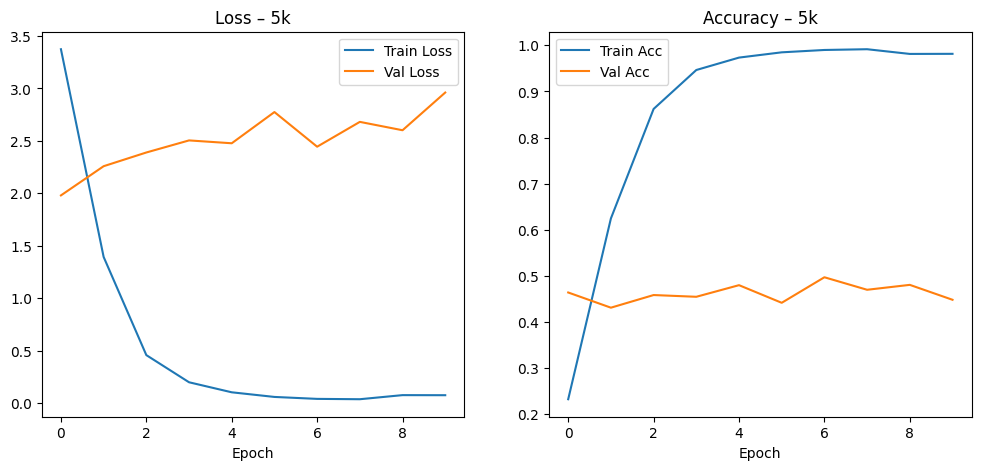


🔍 Metrikák – ViT-B/16 trained on 5k:
✅ Top-1 Accuracy:  0.4482
✅ Top-5 Accuracy:  0.7332
🎯 Precision:       0.4442
🎯 Recall:          0.4805
🎯 F1-score:        0.4364
⏱️ Inference time:  41.93 sec


In [ ]:
model_5k, train_loss_5k, val_loss_5k, train_acc_5k, val_acc_5k = train_on_subset(subsets["5000"], "5k", num_epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_5k, label="Train Loss")
plt.plot(val_loss_5k, label="Val Loss")
plt.title("Loss – 5k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_5k, label="Train Acc")
plt.plot(val_acc_5k, label="Val Acc")
plt.title("Accuracy – 5k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

model_5k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_5k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – ViT-B/16 trained on 5k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


🔷 BLOKK 8 – ViT-B/16 @ 10k részhalmaz


🚀 Tanítás: 10k képes halmaz (ViT-B/16)


Epoch 1/10 - train: 100%|██████████| 155/155 [01:06<00:00,  2.34it/s]


📊 Epoch 1: Train loss=2.5420, acc=0.3893 | Val loss=1.9267, acc=0.4716


Epoch 2/10 - train: 100%|██████████| 155/155 [01:06<00:00,  2.34it/s]


📊 Epoch 2: Train loss=1.0743, acc=0.6928 | Val loss=1.8801, acc=0.5144


...

📊 Epoch 8: Train loss=0.1029, acc=0.9707 | Val loss=2.7910, acc=0.4855


Epoch 9/10 - train: 100%|██████████| 155/155 [01:06<00:00,  2.34it/s]


📊 Epoch 9: Train loss=0.1593, acc=0.9533 | Val loss=2.9414, acc=0.4619


Epoch 10/10 - train: 100%|██████████| 155/155 [01:06<00:00,  2.34it/s]


📊 Epoch 10: Train loss=0.1899, acc=0.9463 | Val loss=2.9566, acc=0.4733


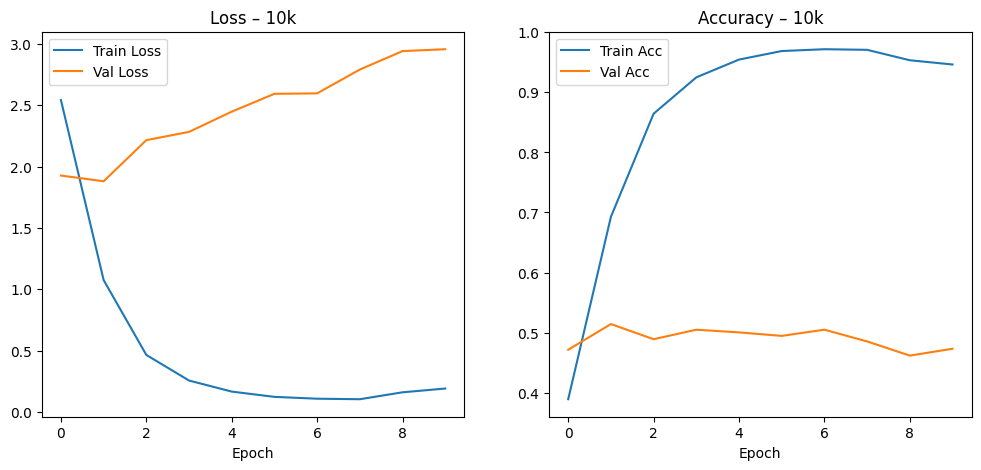


🔍 Metrikák – ViT-B/16 trained on 10k:
✅ Top-1 Accuracy:  0.4782
✅ Top-5 Accuracy:  0.7643
🎯 Precision:       0.4558
🎯 Recall:          0.5071
🎯 F1-score:        0.4540
⏱️ Inference time:  41.93 sec


In [ ]:
model_10k, train_loss_10k, val_loss_10k, train_acc_10k, val_acc_10k = train_on_subset(subsets["10000"], "10k", num_epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_10k, label="Train Loss")
plt.plot(val_loss_10k, label="Val Loss")
plt.title("Loss – 10k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_10k, label="Train Acc")
plt.plot(val_acc_10k, label="Val Acc")
plt.title("Accuracy – 10k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

model_10k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_10k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – ViT-B/16 trained on 10k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


🔷 BLOKK 9 – ViT-B/16 @ 25k részhalmaz


🚀 Tanítás: 25k képes halmaz (ViT-B/16)


Epoch 1/10 - train: 100%|██████████| 391/391 [02:46<00:00,  2.35it/s]


📊 Epoch 1: Train loss=2.0880, acc=0.4653 | Val loss=1.6953, acc=0.5265


Epoch 2/10 - train: 100%|██████████| 391/391 [02:46<00:00,  2.35it/s]


📊 Epoch 2: Train loss=1.0699, acc=0.6904 | Val loss=1.7175, acc=0.5424


...

📊 Epoch 8: Train loss=0.1903, acc=0.9439 | Val loss=2.4245, acc=0.5370


Epoch 9/10 - train: 100%|██████████| 391/391 [02:46<00:00,  2.35it/s]


📊 Epoch 9: Train loss=0.1684, acc=0.9512 | Val loss=2.7019, acc=0.5152


Epoch 10/10 - train: 100%|██████████| 391/391 [02:46<00:00,  2.35it/s]


📊 Epoch 10: Train loss=0.1742, acc=0.9479 | Val loss=2.7032, acc=0.5316


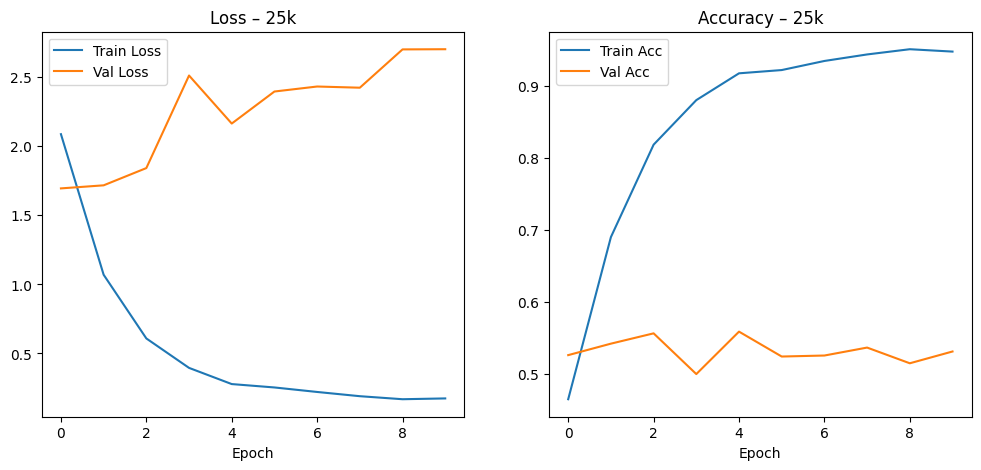


🔍 Metrikák – ViT-B/16 trained on 25k:
✅ Top-1 Accuracy:  0.5335
✅ Top-5 Accuracy:  0.8185
🎯 Precision:       0.5189
🎯 Recall:          0.5908
🎯 F1-score:        0.5308
⏱️ Inference time:  42.08 sec


In [ ]:
model_25k, train_loss_25k, val_loss_25k, train_acc_25k, val_acc_25k = train_on_subset(subsets["25000"], "25k", num_epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_25k, label="Train Loss")
plt.plot(val_loss_25k, label="Val Loss")
plt.title("Loss – 25k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_25k, label="Train Acc")
plt.plot(val_acc_25k, label="Val Acc")
plt.title("Accuracy – 25k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

model_25k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_25k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – ViT-B/16 trained on 25k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


🔷 BLOKK 10 – 📊 Összevont tanulási görbék (Train / Val – Acc és Loss)

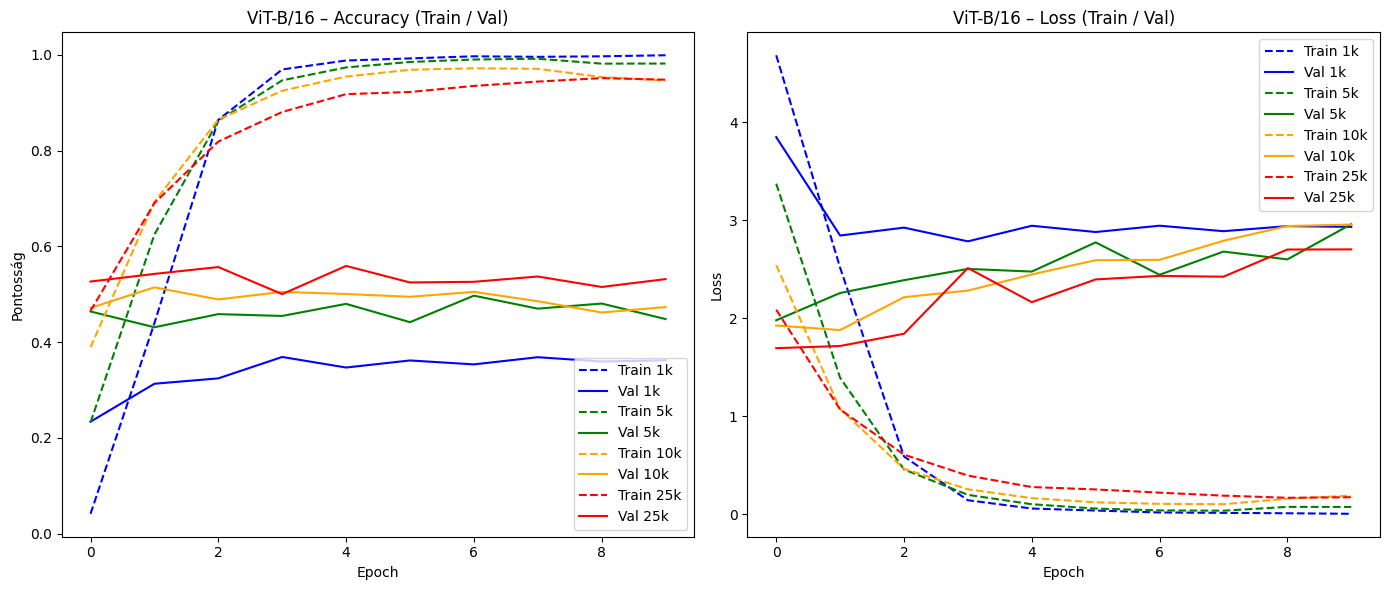

In [ ]:
plt.figure(figsize=(14, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(train_acc_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_acc_1k, label="Val 1k", color='blue')
plt.plot(train_acc_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_acc_5k, label="Val 5k", color='green')
plt.plot(train_acc_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_acc_10k, label="Val 10k", color='orange')
plt.plot(train_acc_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_acc_25k, label="Val 25k", color='red')
plt.title("ViT-B/16 – Accuracy (Train / Val)")
plt.xlabel("Epoch")
plt.ylabel("Pontosság")
plt.legend()

# --- Loss ---
plt.subplot(1, 2, 2)
plt.plot(train_loss_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_loss_1k, label="Val 1k", color='blue')
plt.plot(train_loss_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_loss_5k, label="Val 5k", color='green')
plt.plot(train_loss_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_loss_10k, label="Val 10k", color='orange')
plt.plot(train_loss_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_loss_25k, label="Val 25k", color='red')
plt.title("ViT-B/16 – Loss (Train / Val)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


🔷 BLOKK 11 – 🟦 2×2 Mini Confusion Matrix Montázs

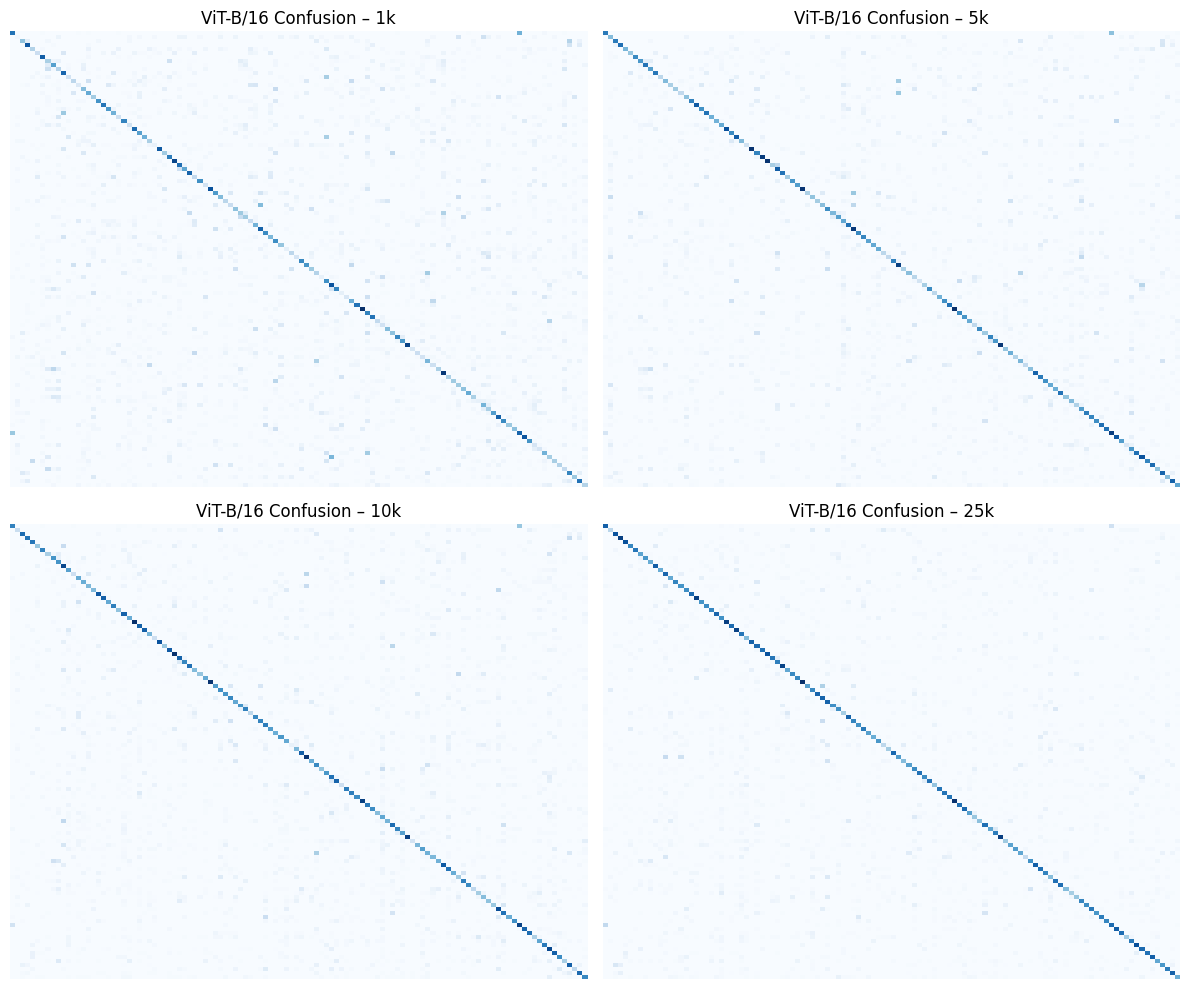

In [ ]:
import seaborn as sns

def plot_mini_confmat(model, title):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            p = torch.argmax(out, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(y.cpu().numpy())

    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(cm_norm, cbar=False, xticklabels=False, yticklabels=False, cmap="Blues")

plt.figure(figsize=(12, 10))
for i, (model, title) in enumerate(zip(
    [model_1k, model_5k, model_10k, model_25k],
    ["1k", "5k", "10k", "25k"]
)):
    plt.subplot(2, 2, i+1)
    plot_mini_confmat(model, title)
    plt.title(f"ViT-B/16 Confusion – {title}")

plt.tight_layout()
plt.show()
